In [1]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

PyTorch version: 2.14.0+cpu
Torchvision version: 0.29.0+cpu
Device: CPU


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision import models

import matplotlib.pyplot as plt
import numpy as np

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

PyTorch: 2.14.0+cpu
Torchvision: 0.29.0+cpu
Device: CPU


In [4]:
# Image transformations and data augmentation

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transformations created successfully.")

Image transformations created successfully.


In [5]:
# Load CIFAR-10 dataset

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))
print("Classes:", train_dataset.classes)

Training images: 50000
Testing images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [13]:
# Prepare CIFAR-10 transforms and DataLoaders for CNN

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Data augmentation for training
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

# Transform for testing
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

# Load datasets
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=test_transform
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created successfully!")
print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

DataLoaders created successfully!
Training batches: 391
Testing batches: 79


In [14]:
# Create Lightweight CNN

import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class CIFAR10_CNN(nn.Module):

    def __init__(self):
        super(CIFAR10_CNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


model = CIFAR10_CNN().to(device)

print("CNN model created successfully!")
print("Device:", device)

CNN model created successfully!
Device: cpu


In [15]:
# Define loss function and optimizer

import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function and optimizer created successfully!")

Loss function and optimizer created successfully!


In [16]:
# Train the CNN

num_epochs = 3

train_accuracies = []
train_losses = []

print("Starting training...")

for epoch in range(num_epochs):
    model.train()

    correct = 0
    total = 0
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = running_loss / len(train_loader)

    train_accuracies.append(accuracy)
    train_losses.append(avg_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {avg_loss:.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )

print("Training completed!")

Starting training...
Epoch [1/3] Loss: 1.4209 Accuracy: 48.50%
Epoch [2/3] Loss: 1.0344 Accuracy: 63.45%
Epoch [3/3] Loss: 0.8759 Accuracy: 69.33%
Training completed!


In [17]:
# Test the trained model

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 71.03%


In [18]:
# Save the trained model

torch.save(model.state_dict(), "cifar10_cnn_model.pth")

print("Model saved successfully!")
print("File: cifar10_cnn_model.pth")

Model saved successfully!
File: cifar10_cnn_model.pth


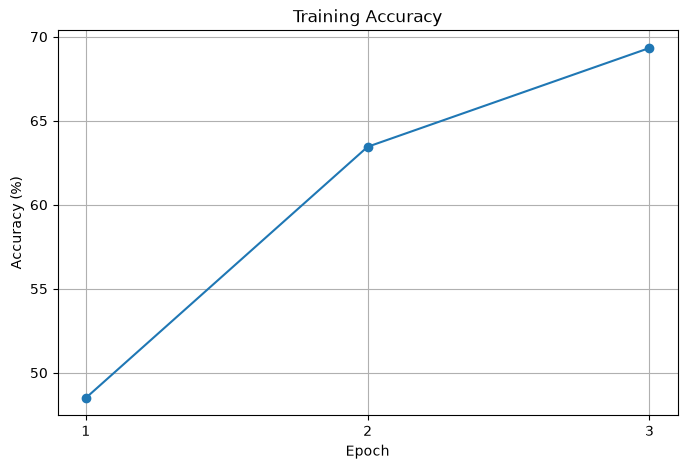

In [19]:
# Plot training accuracy

import matplotlib.pyplot as plt

epochs = [1, 2, 3]
accuracies = [48.50, 63.45, 69.33]

plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracies, marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(epochs)
plt.grid(True)
plt.savefig("Task2_Training_Accuracy.png")
plt.show()

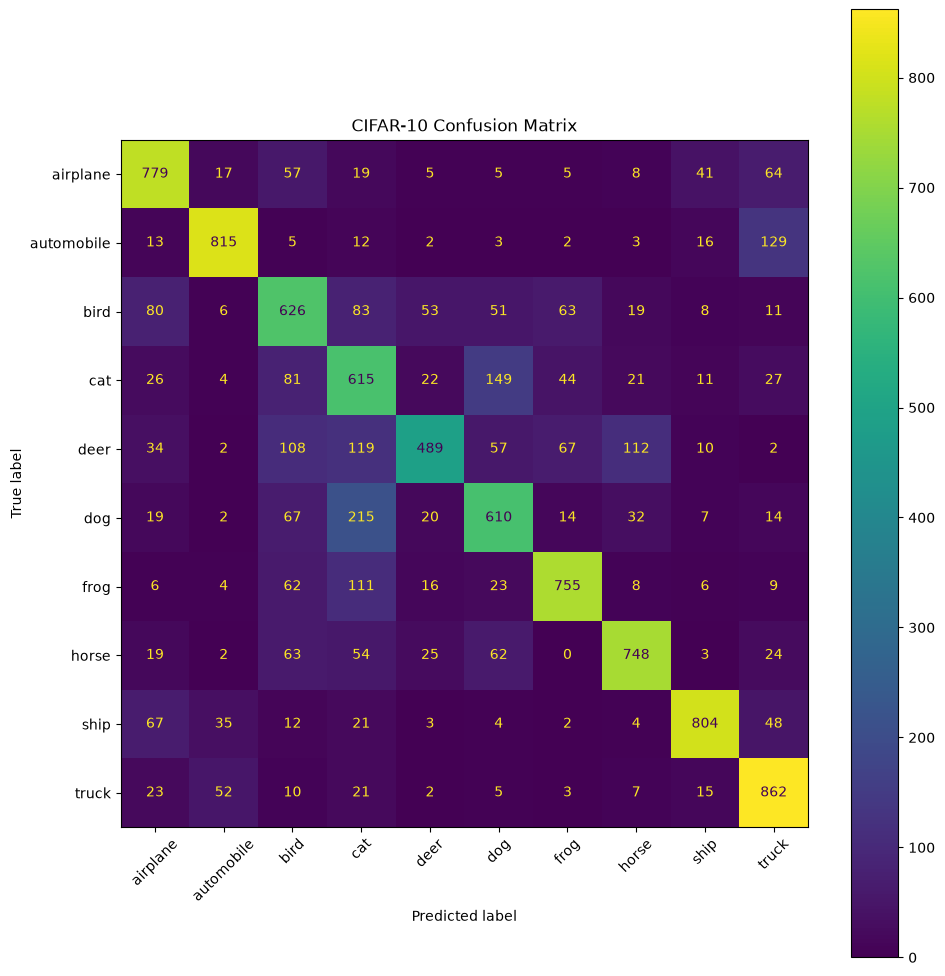

In [21]:
# Create confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("CIFAR-10 Confusion Matrix")
plt.tight_layout()

plt.savefig("Task2_Confusion_Matrix.png")
plt.show()

In [22]:
# Generate classification report

from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=classes
)

print(report)

with open("Task2_Classification_Report.txt", "w") as f:
    f.write(report)

print("\nClassification report saved successfully!")

              precision    recall  f1-score   support

    airplane       0.73      0.78      0.75      1000
  automobile       0.87      0.81      0.84      1000
        bird       0.57      0.63      0.60      1000
         cat       0.48      0.61      0.54      1000
        deer       0.77      0.49      0.60      1000
         dog       0.63      0.61      0.62      1000
        frog       0.79      0.76      0.77      1000
       horse       0.78      0.75      0.76      1000
        ship       0.87      0.80      0.84      1000
       truck       0.72      0.86      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000


Classification report saved successfully!


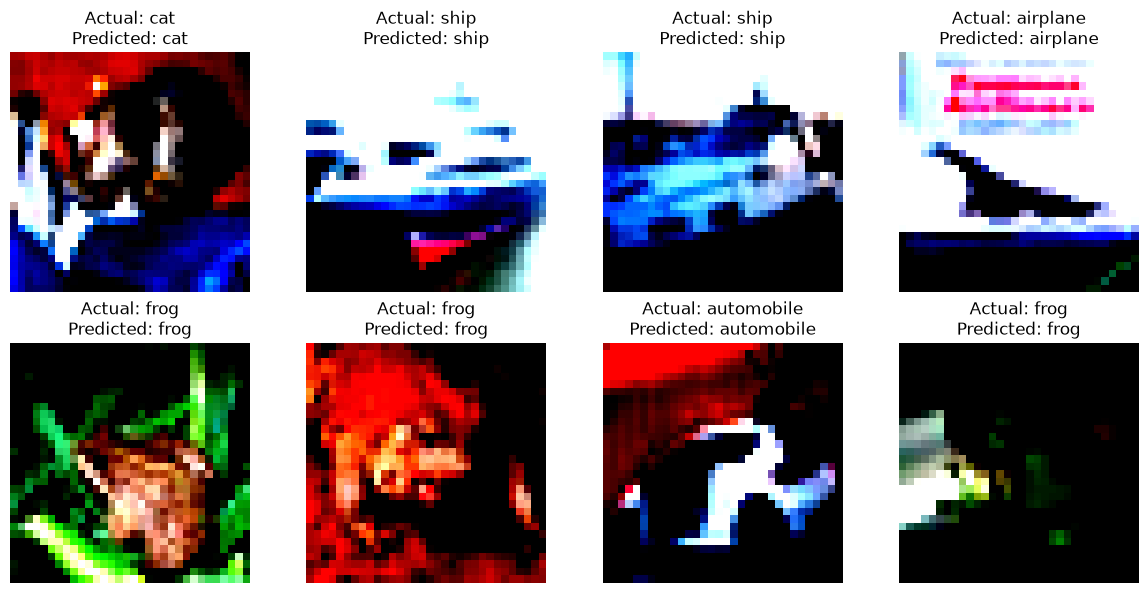

In [23]:
# Show sample predictions

import matplotlib.pyplot as plt
import numpy as np

classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = images[i].cpu().numpy()
    image = np.transpose(image, (1, 2, 0))

    ax.imshow(np.clip(image, 0, 1))
    ax.set_title(
        f"Actual: {classes[labels[i].item()]}\n"
        f"Predicted: {classes[predicted[i].item()]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.savefig("Task2_Inference_Result.png")
plt.show()

In [24]:
# Save Task 2 results

with open("Task2_Results.txt", "w") as f:
    f.write("TASK 2 - DEEP LEARNING CIFAR-10 IMAGE CLASSIFICATION\n")
    f.write("=" * 55 + "\n\n")

    f.write("Model: Lightweight CNN\n")
    f.write("Dataset: CIFAR-10\n")
    f.write("Training Epochs: 3\n\n")

    f.write("Training Accuracy:\n")
    f.write("Epoch 1: 48.50%\n")
    f.write("Epoch 2: 63.45%\n")
    f.write("Epoch 3: 69.33%\n\n")

    f.write(f"Test Accuracy: {test_accuracy:.2f}%\n\n")

    f.write("Generated Files:\n")
    f.write("- cifar10_cnn_model.pth\n")
    f.write("- Task2_Training_Accuracy.png\n")
    f.write("- Task2_Confusion_Matrix.png\n")
    f.write("- Task2_Classification_Report.txt\n")
    f.write("- Task2_Inference_Result.png\n")

print("Task 2 results saved successfully!")

Task 2 results saved successfully!


In [25]:
# Create README file

readme = """# Task 2: Deep Learning – CIFAR-10 Image Classification

## Objective
Build and evaluate a deep learning model for image classification using the CIFAR-10 dataset.

## Dataset
CIFAR-10 contains 60,000 RGB images of size 32×32 belonging to 10 classes:
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

## Model
A lightweight Convolutional Neural Network (CNN) was implemented using PyTorch.

## Training
The model was trained for 3 epochs.

| Epoch | Training Accuracy |
|------|-------------------|
| 1 | 48.50% |
| 2 | 63.45% |
| 3 | 69.33% |

## Test Performance
Test Accuracy: 71.03%

## Data Augmentation
The training data uses image transformations and normalization to improve model generalization.

## Evaluation
The model was evaluated using:
- Test accuracy
- Confusion matrix
- Classification report
- Sample image predictions

## Generated Files
- cifar10_cnn_model.pth
- Task2_Training_Accuracy.png
- Task2_Confusion_Matrix.png
- Task2_Classification_Report.txt
- Task2_Inference_Result.png
- Task2_Results.txt
- Task2_DeepLearning.ipynb

## Environment
Python 3.12
PyTorch
Torchvision
NumPy
Matplotlib
Scikit-learn

## Conclusion
The trained CNN achieved a test accuracy of 71.03% on the CIFAR-10 test dataset.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


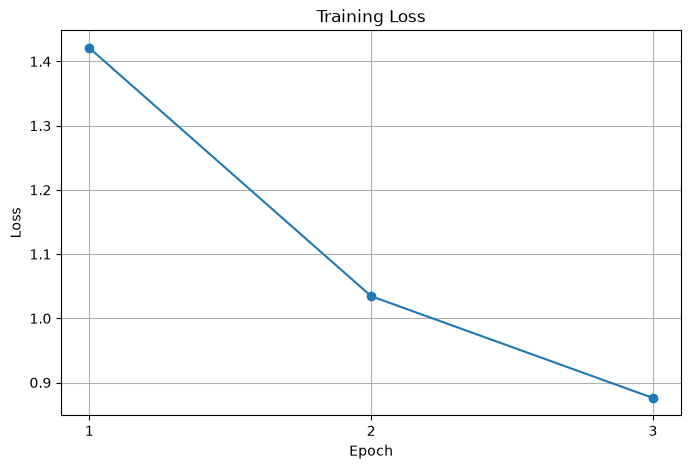

In [26]:
# Plot training loss

import matplotlib.pyplot as plt

epochs = [1, 2, 3]
losses = [1.4209, 1.0344, 0.8759]

plt.figure(figsize=(8, 5))
plt.plot(epochs, losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(True)

plt.savefig("Task2_Training_Loss.png")
plt.show()